# 4.1 Obstacle Detection Pipeline

**Pipeline:** Depth Image -> U-Depth Map -> POI Detection -> Bounding Box -> Ellipsoid -> Kalman Tracking

**Key Equations:**
- Eq(1): $T_{POI} = f \cdot T_{h_o} / d_{bin}$
- Eq(2)-(3): Box position and size from image coordinates
- Eq(4): World frame transformation
- Eq(5): Gaussian data association
- Eq(6): Constant velocity prediction
- Eq(7): $(a,b,c) = \frac{\sqrt{3}}{2}(l,w,h)$

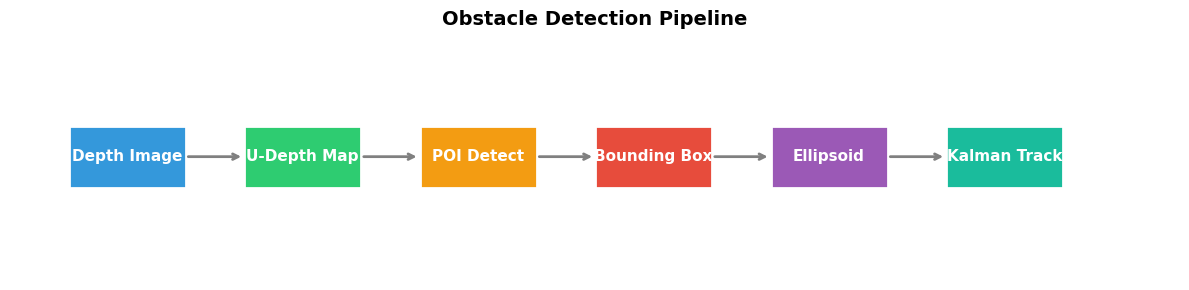

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
import os; os.makedirs('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs', exist_ok=True)

# Visualization: Pipeline stages as flowchart
fig, ax = plt.subplots(figsize=(12, 3))
stages = ['Depth Image', 'U-Depth Map', 'POI Detect', 'Bounding Box', 'Ellipsoid', 'Kalman Track']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']
for i, (s, c) in enumerate(zip(stages, colors)):
    ax.barh(0, 1, left=i*1.5, height=0.5, color=c, edgecolor='white', linewidth=2)
    ax.text(i*1.5+0.5, 0, s, ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    if i < len(stages)-1:
        ax.annotate('', xy=(i*1.5+1.5, 0), xytext=(i*1.5+1.0, 0),
                    arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
ax.set_xlim(-0.5, len(stages)*1.5+0.5); ax.set_ylim(-1, 1)
ax.axis('off')
ax.set_title('Obstacle Detection Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/4.1_pipeline.png', dpi=100, bbox_inches='tight')
plt.show()
